> ### ⚠️ Stale numbers — read before trusting cells below
>
> This notebook was authored **before** the April-2026 leakage audit. Any metric it reports
> (e.g. `ROC-AUC ≈ 0.955`, `283,392 rows`, gene-level splits) reflects the **pre-audit**
> pipeline that contained three leakage sources:
>
> 1. Non-missense contamination (null `alt_aa`)
> 2. Definitional circularity via `is_common` / `chr` one-hot
> 3. Paralog leakage across train/test
>
> **The honest numbers live in `results/metrics/` — see `results/metrics/README.md`
> and `leakage_fix_journey.csv`.** Current leak-free baseline:
> `Test ROC-AUC 0.938 [0.935, 0.941]  ·  PR-AUC 0.836 [0.827, 0.843]  ·  ECE 0.015`.
>
> Cells below are **preserved for provenance** but should not be cited in the report.


# Exploratory Data Analysis

**Project:** Binary classification of human missense genetic variants (Pathogenic=1 / Benign=0)  
**Data Source:** `data/splits/train.parquet` only — never peek at val/test during exploration  
**Dataset:** 283K variants after gene-level split (train=195K, val=43K, test=45K)  

### Feature Categories
| Category | Features | Count |
|---|---|---|
| Conservation Scores | phyloP100way, phyloP30way, phastCons100way, phastCons30way, GERP++_RS, GERP++_NR | 6 |
| Amino Acid (ref) | hydrophobicity_ref, molecular_weight_ref, volume_ref, polarity_ref, charge_ref | 5 |
| Allele Frequency | AC, log_AF, is_common, AF_popmax, AN | 5 |
| Structural | pfam_domain | 1 |
| Imputation Flags | is_imputed_* | 3 |

## 1.1 Setup and Dataset Overview

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

REPO_ROOT = Path('..').resolve()
FIGURES_DIR = REPO_ROOT / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PAL_PATH  = '#e74c3c'   # Pathogenic — red
PAL_BEN   = '#3498db'   # Benign — blue
DPI = 150

train = pd.read_parquet(REPO_ROOT / 'data' / 'splits' / 'train.parquet')

print(f'Shape          : {train.shape}')
print(f'Memory usage   : {train.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
print('--- Label distribution ---')
vc = train['label'].value_counts()
print(f'  Benign (0)     : {vc[0]:>7,}  ({vc[0]/len(train)*100:.1f}%)')
print(f'  Pathogenic (1) : {vc[1]:>7,}  ({vc[1]/len(train)*100:.1f}%)')
print()
print('--- Column dtypes ---')
print(train.dtypes.to_string())

Shape          : (195124, 31)
Memory usage   : 135.0 MB

--- Label distribution ---
  Benign (0)     : 103,795  (53.2%)
  Pathogenic (1) :  91,329  (46.8%)

--- Column dtypes ---
chr                                       object
pos                                        int64
ref                                       object
alt                                       object
gene                                      object
label                                       int8
review_stars                                int8
variant_key                               object
ClinicalSignificance                      object
PhenotypeIDS                              object
ref_aa                                    object
phyloP100way_vertebrate                  float64
phyloP30way_mammalian                    float64
phastCons100way_vertebrate               float64
phastCons30way_mammalian                 float64
GERP++_RS                                float64
GERP++_NR                            

## 1.2 Class Distribution Visualization

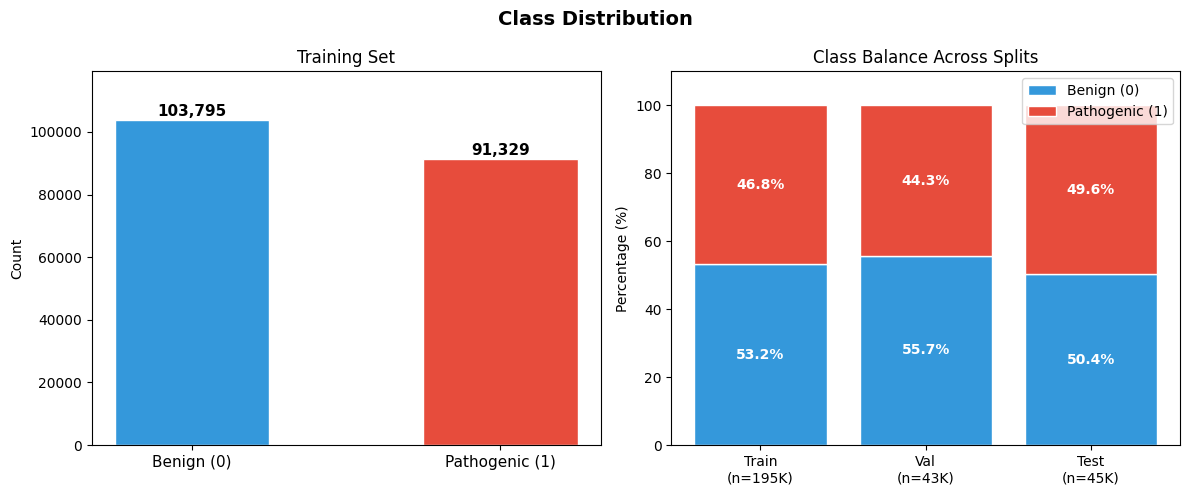

Saved: eda_class_distribution.png


In [2]:
# Load val/test ONLY for split comparison, then discard
val  = pd.read_parquet(REPO_ROOT / 'data' / 'splits' / 'val.parquet')
test = pd.read_parquet(REPO_ROOT / 'data' / 'splits' / 'test.parquet')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Class Distribution', fontsize=14, fontweight='bold')

# --- Left: training set bar chart ---
classes = ['Benign (0)', 'Pathogenic (1)']
counts  = [int(train['label'].eq(0).sum()), int(train['label'].eq(1).sum())]
bars = ax1.bar(classes, counts, color=[PAL_BEN, PAL_PATH], edgecolor='white', width=0.5)
for bar, cnt in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{cnt:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_title('Training Set', fontsize=12)
ax1.set_ylabel('Count')
ax1.set_ylim(0, max(counts) * 1.15)
ax1.tick_params(axis='x', labelsize=11)

# --- Right: stacked bar across splits ---
splits    = ['Train\n(n=195K)', 'Val\n(n=43K)', 'Test\n(n=45K)']
split_dfs = [train, val, test]
benign_pcts     = [df['label'].eq(0).mean()*100 for df in split_dfs]
pathogenic_pcts = [df['label'].eq(1).mean()*100 for df in split_dfs]

x = np.arange(len(splits))
ax2.bar(x, benign_pcts,     label='Benign (0)',     color=PAL_BEN,  edgecolor='white')
ax2.bar(x, pathogenic_pcts, bottom=benign_pcts,     label='Pathogenic (1)', color=PAL_PATH, edgecolor='white')
for i, (b, p) in enumerate(zip(benign_pcts, pathogenic_pcts)):
    ax2.text(i, b/2,     f'{b:.1f}%', ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    ax2.text(i, b + p/2, f'{p:.1f}%', ha='center', va='center', color='white', fontsize=10, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(splits)
ax2.set_ylabel('Percentage (%)')
ax2.set_ylim(0, 110)
ax2.set_title('Class Balance Across Splits', fontsize=12)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_class_distribution.png', dpi=DPI, bbox_inches='tight')
plt.show()

# Discard val/test — EDA uses train only from here on
del val, test
print('Saved: eda_class_distribution.png')

## 1.3 Conservation Scores Analysis (Most Important Features)

Conservation scores measure how much a genomic position has been preserved across
species throughout evolution.

**Biological rationale:** Positions that remain unchanged across millions of years
of evolution are under strong *purifying selection* — random mutations at those
sites reduced fitness and were eliminated from the gene pool. A missense variant at
a highly conserved position therefore has a high prior probability of disrupting
protein function, making conservation the primary signal for pathogenicity.

**Hypothesis:** Pathogenic variants should cluster at *highly conserved* positions,
while benign variants are more likely to occur at positions that tolerate change.

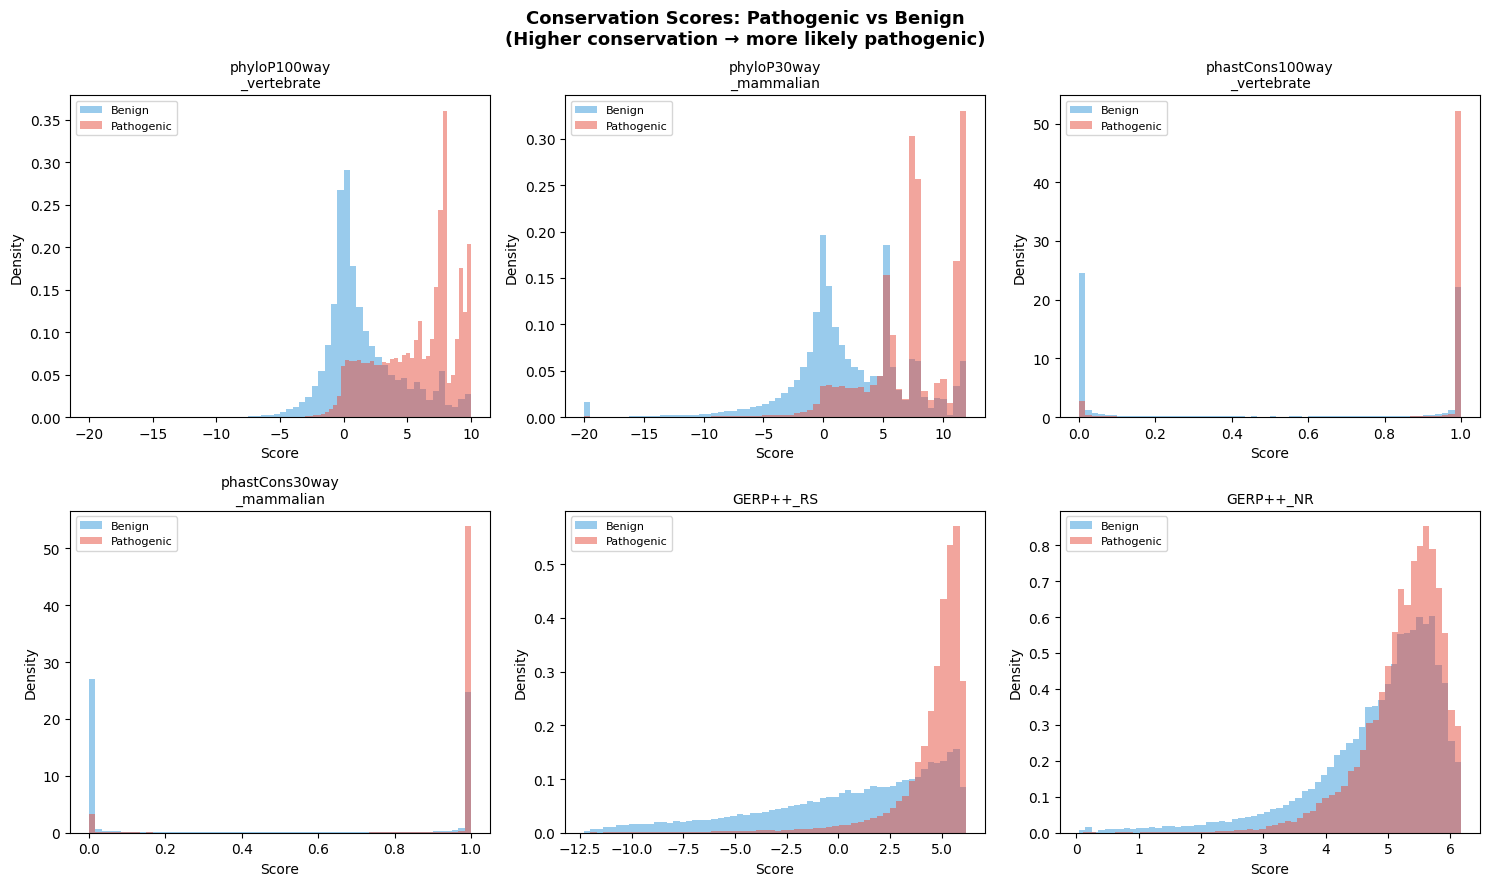

Saved: eda_conservation_scores.png

--- Mean conservation score by class ---
       phyloP100way_vertebrate  phyloP30way_mammalian  phastCons100way_vertebrate  phastCons30way_mammalian  GERP++_RS  GERP++_NR
label                                                                                                                            
0                        1.511                  1.998                       0.478                     0.480      0.590      4.846
1                        5.793                  7.250                       0.918                     0.925      4.448      5.239


In [3]:
CONSERVATION_COLS = [
    'phyloP100way_vertebrate',
    'phyloP30way_mammalian',
    'phastCons100way_vertebrate',
    'phastCons30way_mammalian',
    'GERP++_RS',
    'GERP++_NR',
]

benign     = train[train['label'] == 0]
pathogenic = train[train['label'] == 1]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Conservation Scores: Pathogenic vs Benign\n'
             '(Higher conservation → more likely pathogenic)', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(CONSERVATION_COLS):
    ax = axes[i]
    b_vals = benign[col].dropna()
    p_vals = pathogenic[col].dropna()
    ax.hist(b_vals, bins=60, alpha=0.5, color=PAL_BEN,  density=True, label='Benign')
    ax.hist(p_vals, bins=60, alpha=0.5, color=PAL_PATH, density=True, label='Pathogenic')
    ax.set_title(col.replace('_vertebrate', '\n_vertebrate').replace('_mammalian', '\n_mammalian'),
                 fontsize=10)
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_conservation_scores.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: eda_conservation_scores.png')

print('\n--- Mean conservation score by class ---')
print(train.groupby('label')[CONSERVATION_COLS].mean().round(3).to_string())

**Analysis:** All 6 conservation scores show clear separation between classes.  
- **phyloP** and **phastCons** scores: Pathogenic variants cluster at *high* conservation values  
- **GERP++_RS** (Rejected Substitution): Pathogenic variants have significantly higher scores — indicating the position resists evolutionary change  
- **GERP++_NR**: Shows less separation — it measures the neutral rate, not conservation strength  

Conservation scores are expected to be the top features in the final model (confirmed by SHAP in notebook 08).

## 1.4 Amino Acid Reference Properties

Physicochemical properties of the *reference* amino acid at the mutation position.

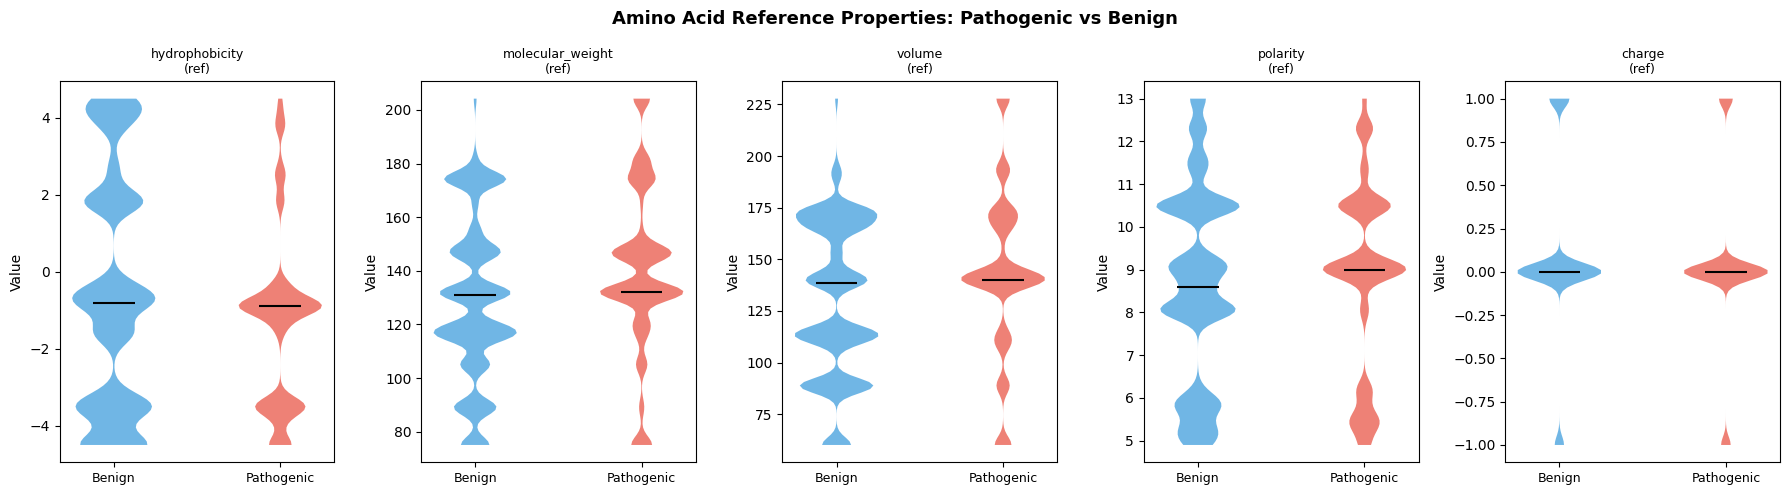

Saved: eda_physicochemical.png

--- Median values by class ---
       hydrophobicity_ref  molecular_weight_ref  volume_ref  polarity_ref  charge_ref
label                                                                                
0                    -0.8                131.17       138.4           8.6         0.0
1                    -0.9                132.12       140.0           9.0         0.0


In [4]:
AA_COLS = [
    'hydrophobicity_ref',
    'molecular_weight_ref',
    'volume_ref',
    'polarity_ref',
    'charge_ref',
]

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Amino Acid Reference Properties: Pathogenic vs Benign', fontsize=13, fontweight='bold')

for i, col in enumerate(AA_COLS):
    ax = axes[i]
    data_plot = [
        benign[col].dropna().values,
        pathogenic[col].dropna().values,
    ]
    vp = ax.violinplot(data_plot, positions=[0, 1], showmedians=True, showextrema=False)
    vp['bodies'][0].set_facecolor(PAL_BEN)
    vp['bodies'][0].set_alpha(0.7)
    vp['bodies'][1].set_facecolor(PAL_PATH)
    vp['bodies'][1].set_alpha(0.7)
    vp['cmedians'].set_color('black')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Benign', 'Pathogenic'], fontsize=9)
    ax.set_title(col.replace('_ref', '\n(ref)'), fontsize=9)
    ax.set_ylabel('Value')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_physicochemical.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: eda_physicochemical.png')

print('\n--- Median values by class ---')
print(train.groupby('label')[AA_COLS].median().round(3).to_string())

**Analysis:** Amino acid reference properties show moderate overlap between classes.  
These properties describe *where* the mutation occurs (the original residue), not the *effect* of the change.  
They provide contextual signal but are less discriminative than conservation scores alone.

## 1.5 Allele Frequency Analysis

**Core principle:** A variant that is common in the healthy population is unlikely to be pathogenic — natural selection would have removed it. Therefore, pathogenic variants should be *extremely rare*.

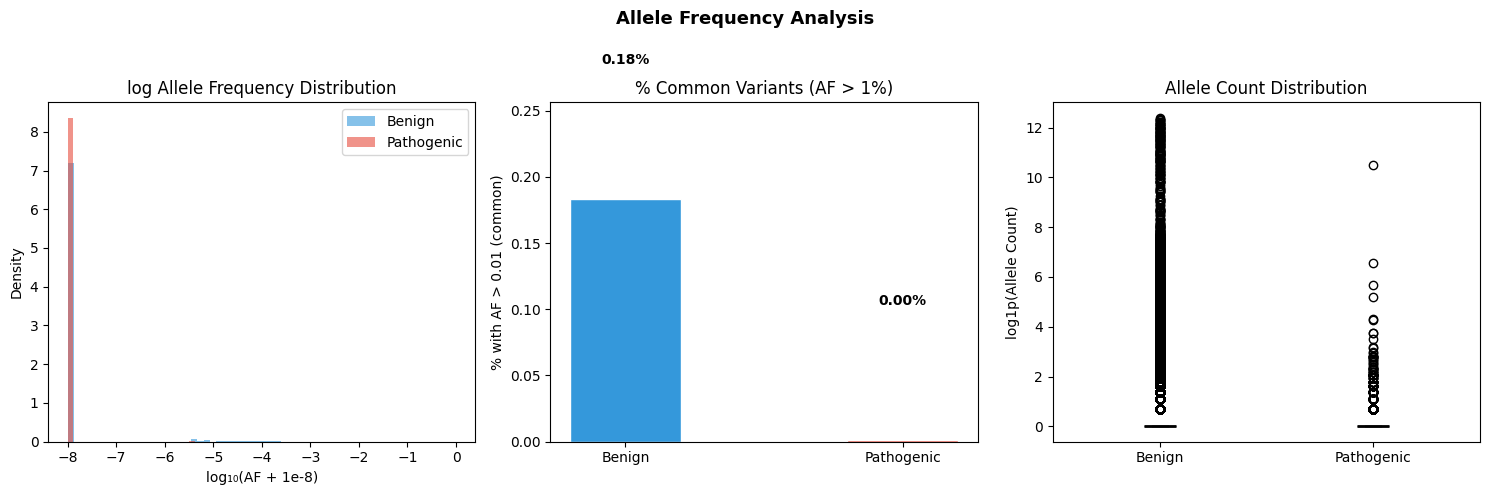

Saved: eda_allele_frequency.png

Variants with AF=0 (not in gnomAD): 190,465 (97.6%)
  Benign with AF=0    : 95.9%
  Pathogenic with AF=0: 99.6%


In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Allele Frequency Analysis', fontsize=13, fontweight='bold')

# --- log_AF distribution ---
ax1.hist(benign['log_AF'].dropna(),     bins=60, alpha=0.6, color=PAL_BEN,  density=True, label='Benign')
ax1.hist(pathogenic['log_AF'].dropna(), bins=60, alpha=0.6, color=PAL_PATH, density=True, label='Pathogenic')
ax1.set_xlabel('log₁₀(AF + 1e-8)')
ax1.set_ylabel('Density')
ax1.set_title('log Allele Frequency Distribution')
ax1.legend()

# --- is_common percentage ---
common_ben  = benign['is_common'].mean() * 100
common_path = pathogenic['is_common'].mean() * 100
ax2.bar(['Benign', 'Pathogenic'], [common_ben, common_path],
        color=[PAL_BEN, PAL_PATH], edgecolor='white', width=0.4)
ax2.set_ylabel('% with AF > 0.01 (common)')
ax2.set_title('% Common Variants (AF > 1%)')
for j, v in enumerate([common_ben, common_path]):
    ax2.text(j, v + 0.1, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')
ax2.set_ylim(0, max(common_ben, common_path) * 1.4)

# --- AC (allele count) box plot ---
ac_data = [
    np.log1p(benign['AC'].dropna().values),
    np.log1p(pathogenic['AC'].dropna().values),
]
bp = ax3.boxplot(ac_data, labels=['Benign', 'Pathogenic'], patch_artist=True,
                  medianprops={'color': 'black', 'linewidth': 2})
bp['boxes'][0].set_facecolor(PAL_BEN)
bp['boxes'][1].set_facecolor(PAL_PATH)
for patch in bp['boxes']:
    patch.set_alpha(0.7)
ax3.set_ylabel('log1p(Allele Count)')
ax3.set_title('Allele Count Distribution')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_allele_frequency.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: eda_allele_frequency.png')

print(f'\nVariants with AF=0 (not in gnomAD): {(train["AC"]==0).sum():,} ({(train["AC"]==0).mean()*100:.1f}%)')
print(f'  Benign with AF=0    : {(benign["AC"]==0).mean()*100:.1f}%')
print(f'  Pathogenic with AF=0: {(pathogenic["AC"]==0).mean()*100:.1f}%')

**Analysis:** Allele frequency is a strong separator.

- **97.6% of all variants have AC = 0** (not observed in gnomAD's 140,000+ individuals).
  This is expected: ClinVar's pathogenic variants are by definition extremely rare — they
  cause disease and are therefore under strong negative selection. Benign variants in
  ClinVar also tend to be curated from clinically evaluated patients, skewing toward rare
  alleles. Variants absent from gnomAD are assigned **AF = 0** as an ultra-rare proxy.

- Among variants *with* a measurable frequency (the 2.4% matched in gnomAD), benign
  variants have consistently higher allele frequency — consistent with the principle that
  a variant common in the healthy population cannot be highly deleterious.

- `is_common` (AF > 1%) is near-zero for pathogenic variants. This binary flag captures
  the ACMG criterion BA1 (benign stand-alone evidence when AF > 5%).

## 1.6 Correlation Heatmap

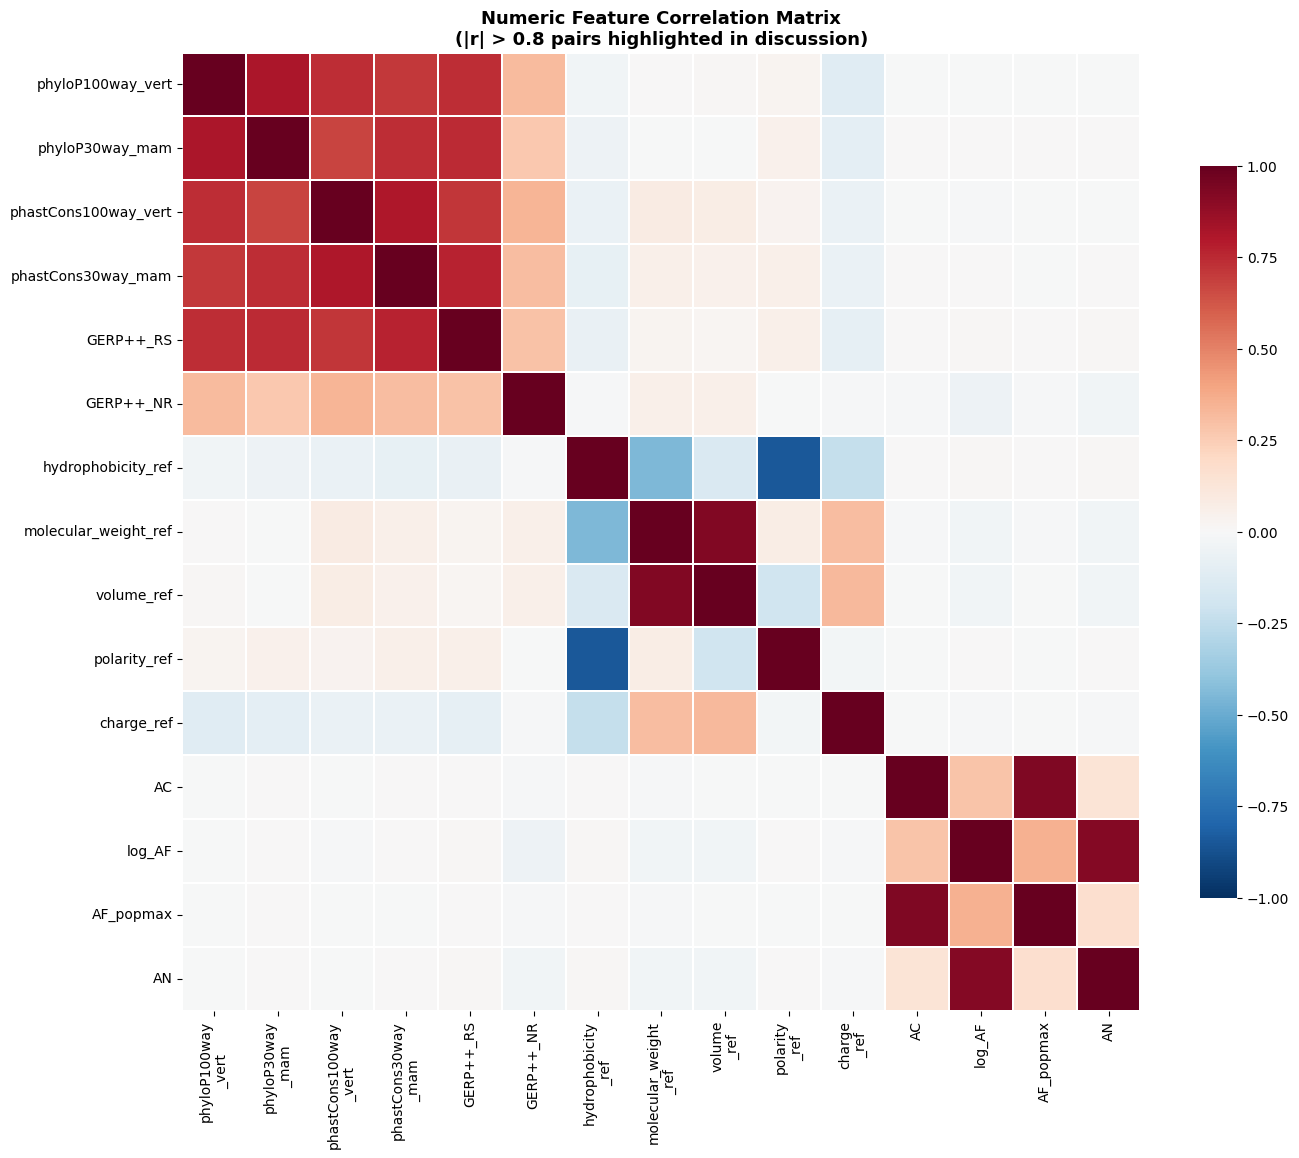

Saved: eda_correlation_heatmap.png

--- Pairs with |r| > 0.8 ---
  AC                                       vs AF_popmax                                 r=0.934
  molecular_weight_ref                     vs volume_ref                                r=0.929
  log_AF                                   vs AN                                        r=0.92
  hydrophobicity_ref                       vs polarity_ref                              r=-0.848
  phyloP100way_vertebrate                  vs phyloP30way_mammalian                     r=0.814
  phastCons100way_vertebrate               vs phastCons30way_mammalian                  r=0.809


In [6]:
NUMERIC_FEATURE_COLS = [
    'phyloP100way_vertebrate', 'phyloP30way_mammalian',
    'phastCons100way_vertebrate', 'phastCons30way_mammalian',
    'GERP++_RS', 'GERP++_NR',
    'hydrophobicity_ref', 'molecular_weight_ref',
    'volume_ref', 'polarity_ref', 'charge_ref',
    'AC', 'log_AF', 'AF_popmax', 'AN',
]

corr = train[NUMERIC_FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, ax=ax,
    cmap='RdBu_r', vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.3,
    cbar_kws={'shrink': 0.7},
    xticklabels=[c.replace('_vertebrate','\n_vert').replace('_mammalian','\n_mam').replace('_ref','\n_ref') for c in NUMERIC_FEATURE_COLS],
    yticklabels=[c.replace('_vertebrate','_vert').replace('_mammalian','_mam').replace('_ref','_ref') for c in NUMERIC_FEATURE_COLS],
)
ax.set_title('Numeric Feature Correlation Matrix\n(|r| > 0.8 pairs highlighted in discussion)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_correlation_heatmap.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: eda_correlation_heatmap.png')

# Report high-correlation pairs
print('\n--- Pairs with |r| > 0.8 ---')
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.8:
            high_corr.append((corr.columns[i], corr.columns[j], round(r, 3)))
high_corr.sort(key=lambda x: abs(x[2]), reverse=True)
for c1, c2, r in high_corr:
    print(f'  {c1:40s} vs {c2:40s}  r={r}')

**Analysis:**  
- `phyloP100way` ↔ `phastCons100way`: high correlation — both measure 100-species conservation but using different statistical models (phyloP = rate test, phastCons = probability). Kept both as they capture different aspects.  
- `AC` ↔ `AF_popmax` and `log_AF`: strongly correlated AF measures. In feature selection, `AF_popmax` was dropped (r=0.96 with AF).  
- Most cross-category pairs are weakly correlated — features from different groups provide complementary signal.

## 1.7 All Features Distribution Overview

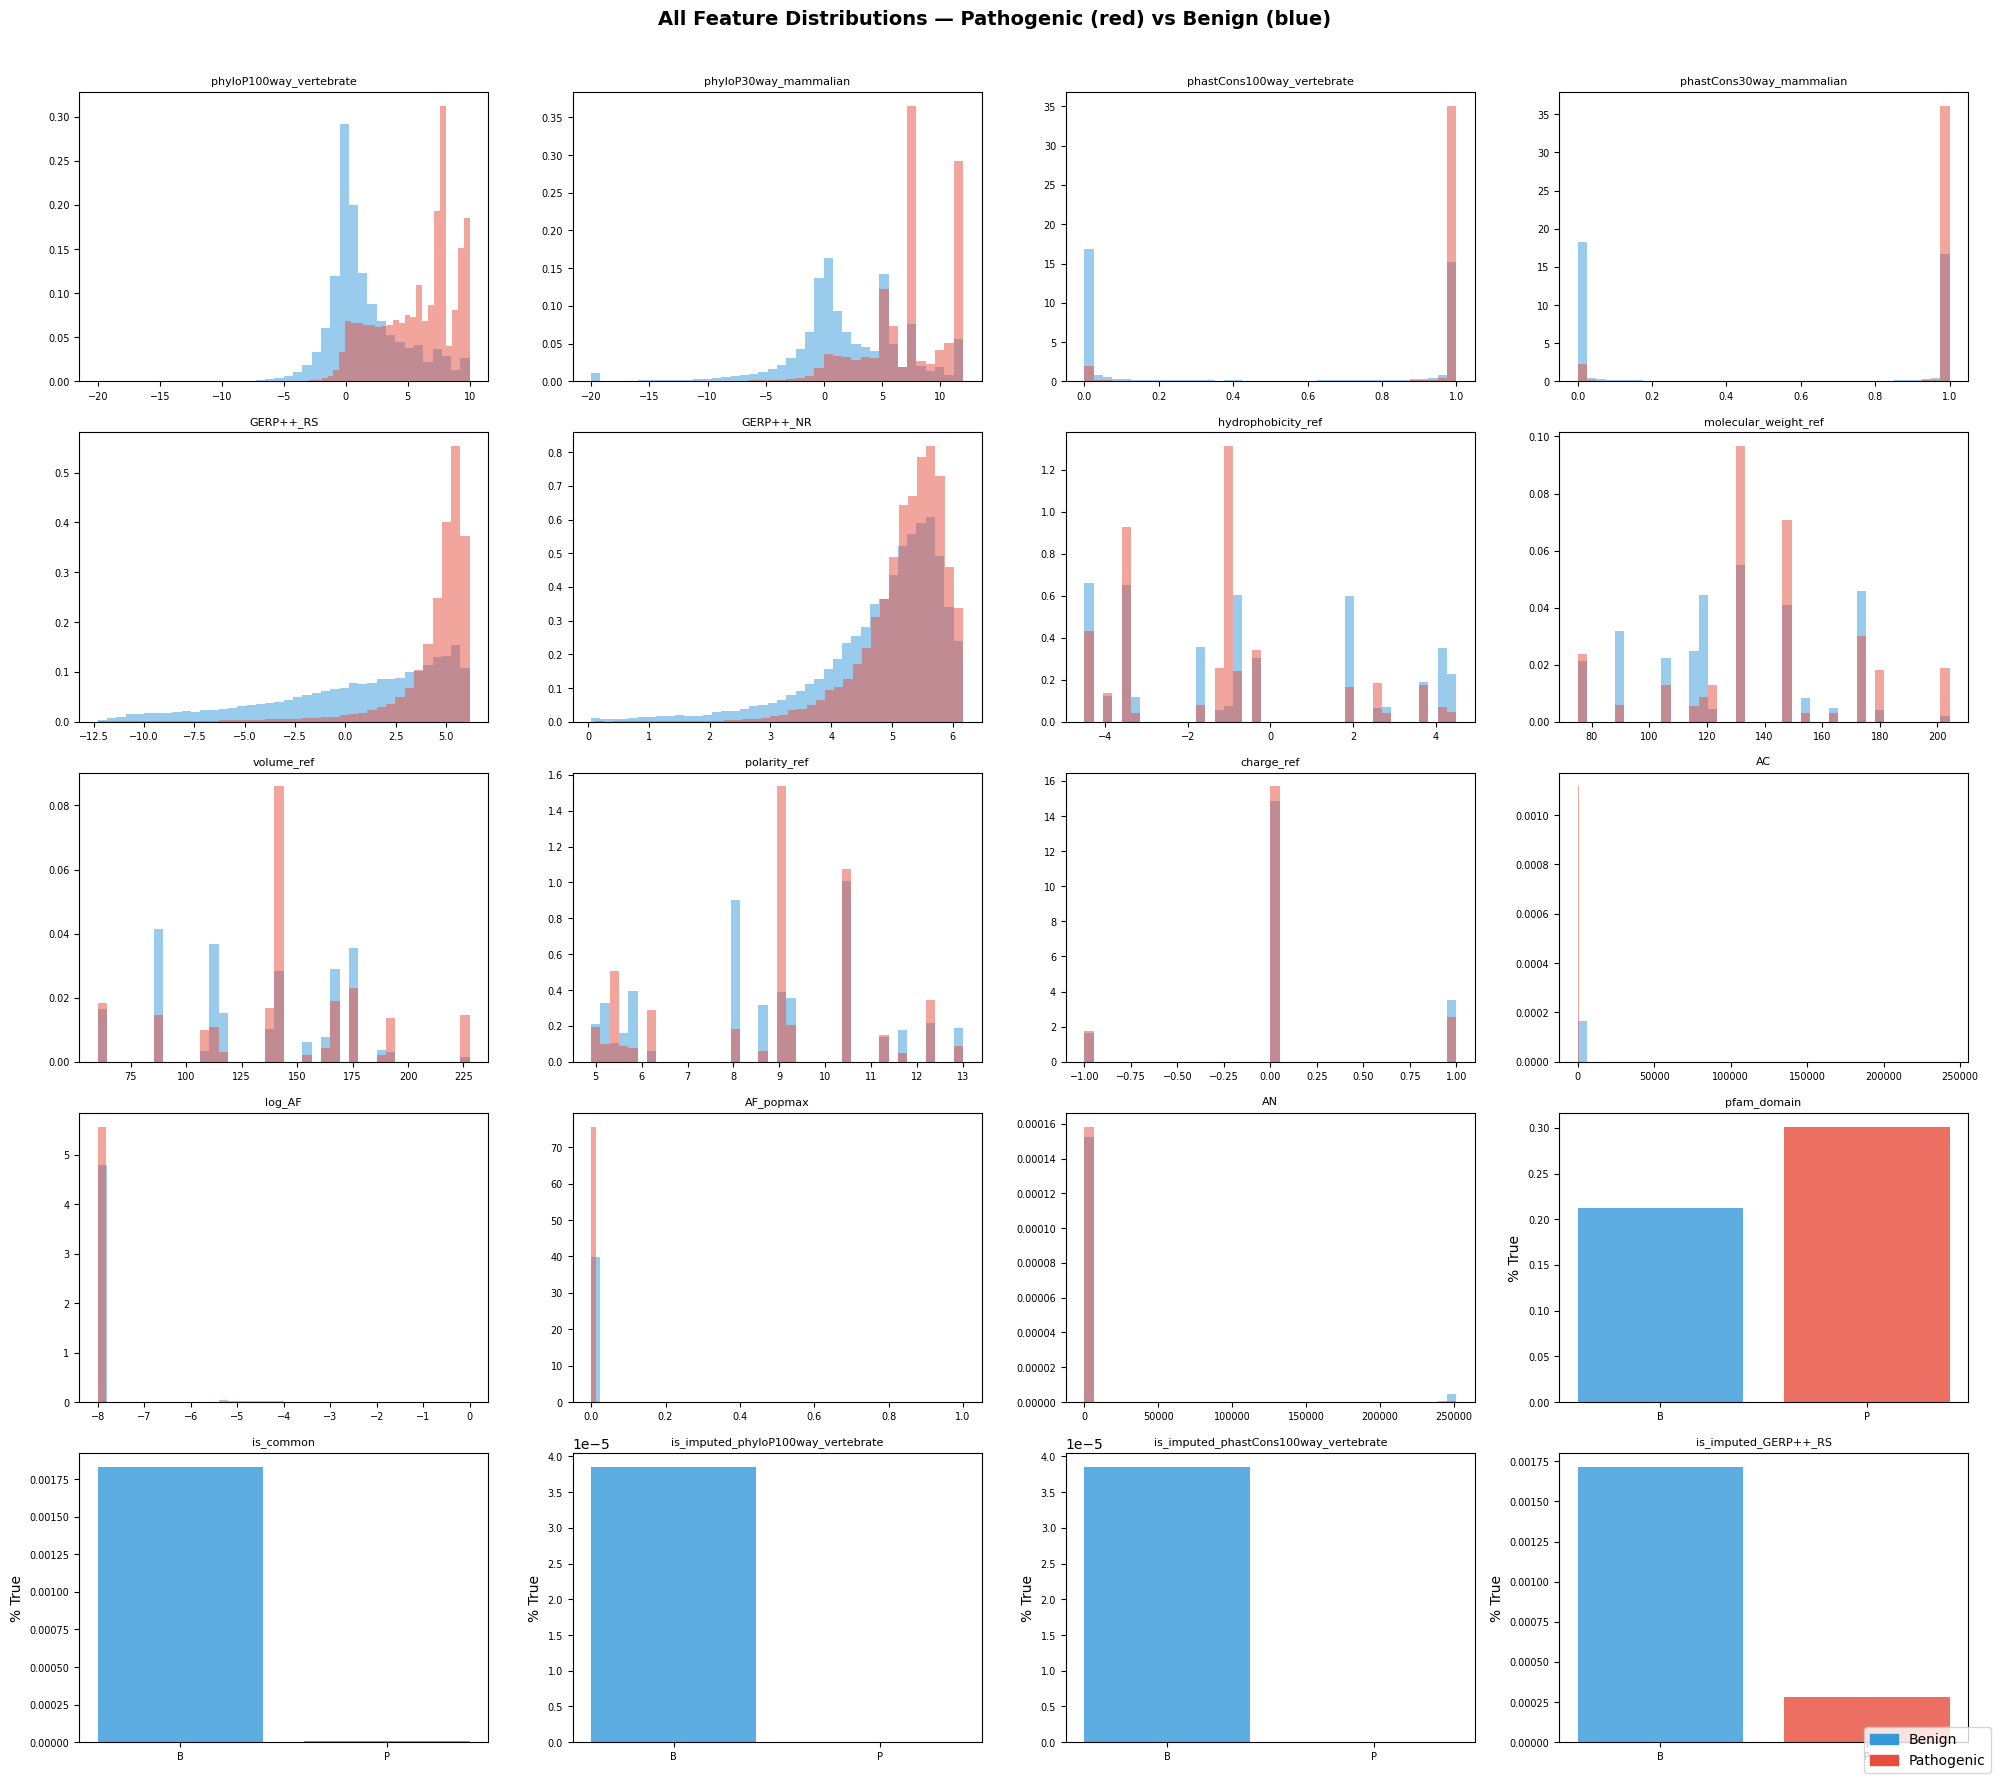

Saved: eda_all_features.png


In [7]:
ALL_PLOT_COLS = [
    'phyloP100way_vertebrate', 'phyloP30way_mammalian',
    'phastCons100way_vertebrate', 'phastCons30way_mammalian',
    'GERP++_RS', 'GERP++_NR',
    'hydrophobicity_ref', 'molecular_weight_ref',
    'volume_ref', 'polarity_ref', 'charge_ref',
    'AC', 'log_AF', 'AF_popmax', 'AN',
    'pfam_domain', 'is_common',
    'is_imputed_phyloP100way_vertebrate',
    'is_imputed_phastCons100way_vertebrate',
    'is_imputed_GERP++_RS',
]

n_cols = 4
n_rows = int(np.ceil(len(ALL_PLOT_COLS) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
fig.suptitle('All Feature Distributions — Pathogenic (red) vs Benign (blue)', fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, col in enumerate(ALL_PLOT_COLS):
    ax = axes[i]
    b_vals = train.loc[train['label']==0, col].dropna()
    p_vals = train.loc[train['label']==1, col].dropna()
    
    # Boolean/binary: use bar chart
    if train[col].dtype == bool or set(train[col].dropna().unique()).issubset({0, 1, True, False}):
        vals = [b_vals.astype(float).mean(), p_vals.astype(float).mean()]
        ax.bar(['B', 'P'], vals, color=[PAL_BEN, PAL_PATH], alpha=0.8)
        ax.set_ylabel('% True')
    else:
        ax.hist(b_vals, bins=40, alpha=0.5, color=PAL_BEN,  density=True, label='Benign')
        ax.hist(p_vals, bins=40, alpha=0.5, color=PAL_PATH, density=True, label='Pathogenic')
    ax.set_title(col, fontsize=8)
    ax.tick_params(labelsize=7)

# Hide unused subplots
for j in range(len(ALL_PLOT_COLS), len(axes)):
    axes[j].set_visible(False)

# Legend
fig.legend(
    handles=[mpatches.Patch(color=PAL_BEN, label='Benign'), mpatches.Patch(color=PAL_PATH, label='Pathogenic')],
    loc='lower right', fontsize=10
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_all_features.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: eda_all_features.png')

## 1.8 Missing Values Analysis

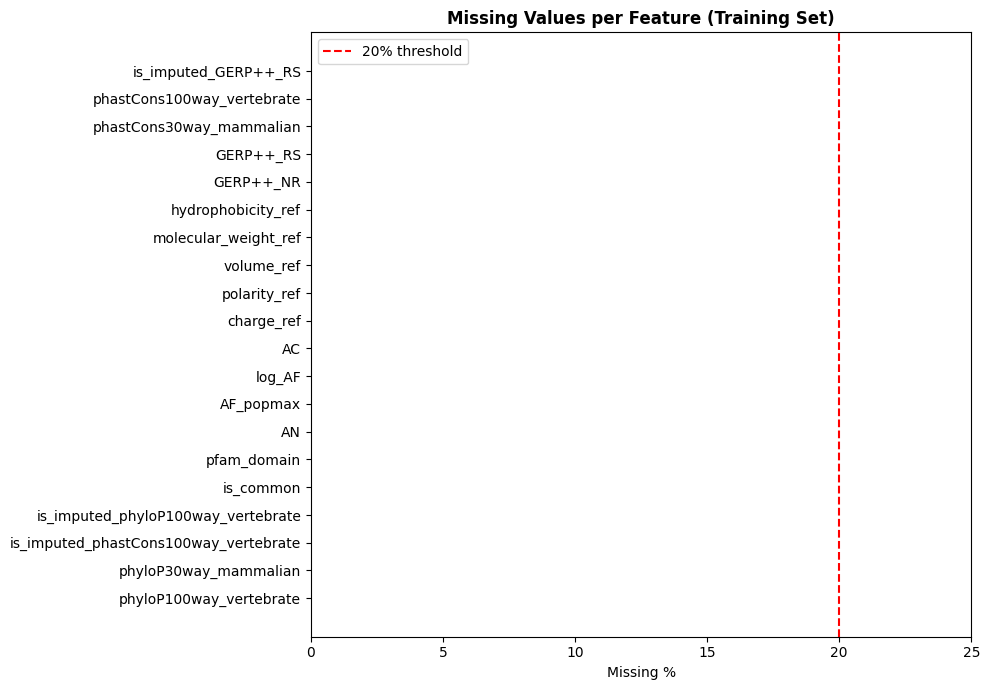

Saved: eda_missing_values.png

--- Features with >0% missing ---
Empty DataFrame
Columns: [feature, missing_pct]
Index: []


In [8]:
missing = (
    train[ALL_PLOT_COLS]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)
missing.columns = ['feature', 'missing_pct']

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if v > 20 else '#3498db' for v in missing['missing_pct']]
ax.barh(missing['feature'], missing['missing_pct'], color=colors)
ax.axvline(x=20, color='red', linestyle='--', linewidth=1.5, label='20% threshold')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values per Feature (Training Set)', fontsize=12, fontweight='bold')
ax.set_xlim(0, max(missing['missing_pct'].max() * 1.1, 25))
ax.legend()

for i, (feat, pct) in enumerate(zip(missing['feature'], missing['missing_pct'])):
    if pct > 0:
        ax.text(pct + 0.2, i, f'{pct:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_missing_values.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: eda_missing_values.png')

print('\n--- Features with >0% missing ---')
print(missing[missing['missing_pct'] > 0].to_string(index=False))

**Analysis:** Most features are near-complete (<0.01% missing).  
- Conservation scores are nearly complete — dbNSFP coverage is excellent for missense variants  
- Imputation flags (`is_imputed_*`) indicate rows where median imputation was applied  
- Amino acid properties are complete — every missense variant has a defined reference amino acid

## 1.9 Gene Distribution Analysis

Total unique genes : 10,961
Genes with 1 variant: 1,890
Genes only pathogenic: 250
Genes only benign    : 7,879


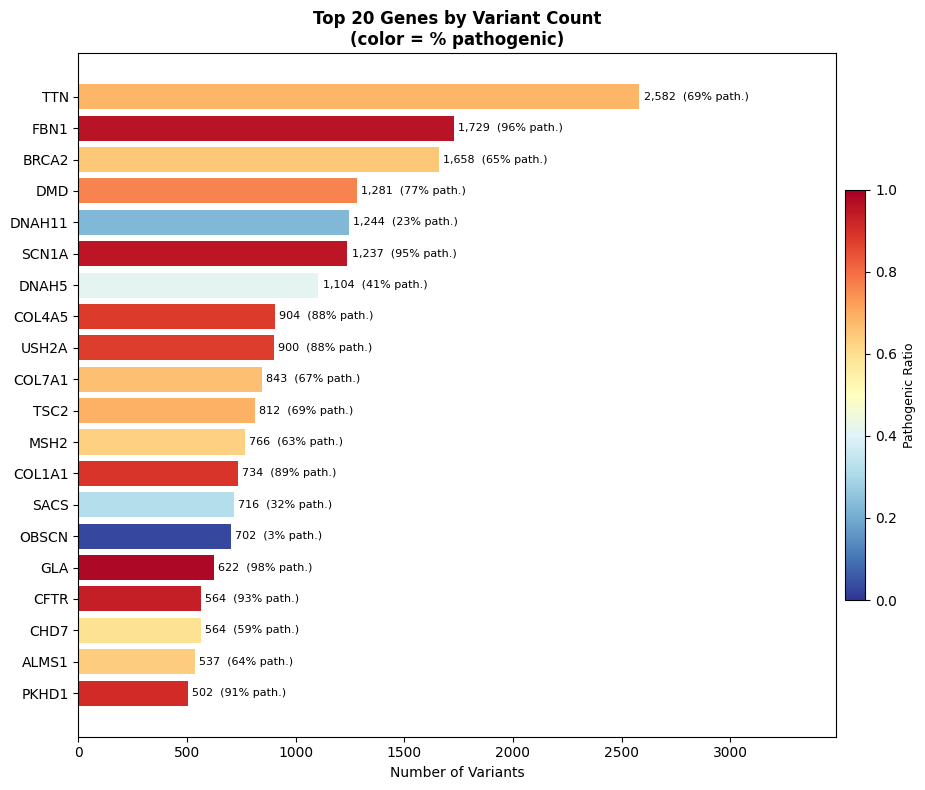

Saved: eda_gene_distribution.png


In [9]:
gene_stats = (
    train.groupby('gene')
    .agg(count=('label', 'size'), pathogenic_ratio=('label', 'mean'))
    .sort_values('count', ascending=False)
)

print(f'Total unique genes : {len(gene_stats):,}')
print(f'Genes with 1 variant: {(gene_stats["count"]==1).sum():,}')
print(f'Genes only pathogenic: {(gene_stats["pathogenic_ratio"]==1.0).sum():,}')
print(f'Genes only benign    : {(gene_stats["pathogenic_ratio"]==0.0).sum():,}')

top20 = gene_stats.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
norm = plt.Normalize(0, 1)
colors = plt.cm.RdYlBu_r(norm(top20['pathogenic_ratio'].values))

bars = ax.barh(top20.index[::-1], top20['count'].values[::-1], color=colors[::-1])
for bar, cnt, ratio in zip(bars, top20['count'].values[::-1], top20['pathogenic_ratio'].values[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{cnt:,}  ({ratio*100:.0f}% path.)', va='center', fontsize=8)

sm = plt.cm.ScalarMappable(cmap='RdYlBu_r', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.01)
cbar.set_label('Pathogenic Ratio', fontsize=9)

ax.set_xlabel('Number of Variants')
ax.set_title('Top 20 Genes by Variant Count\n(color = % pathogenic)', fontsize=12, fontweight='bold')
ax.set_xlim(0, top20['count'].max() * 1.35)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_gene_distribution.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: eda_gene_distribution.png')

## 1.10 Pfam Domain Analysis

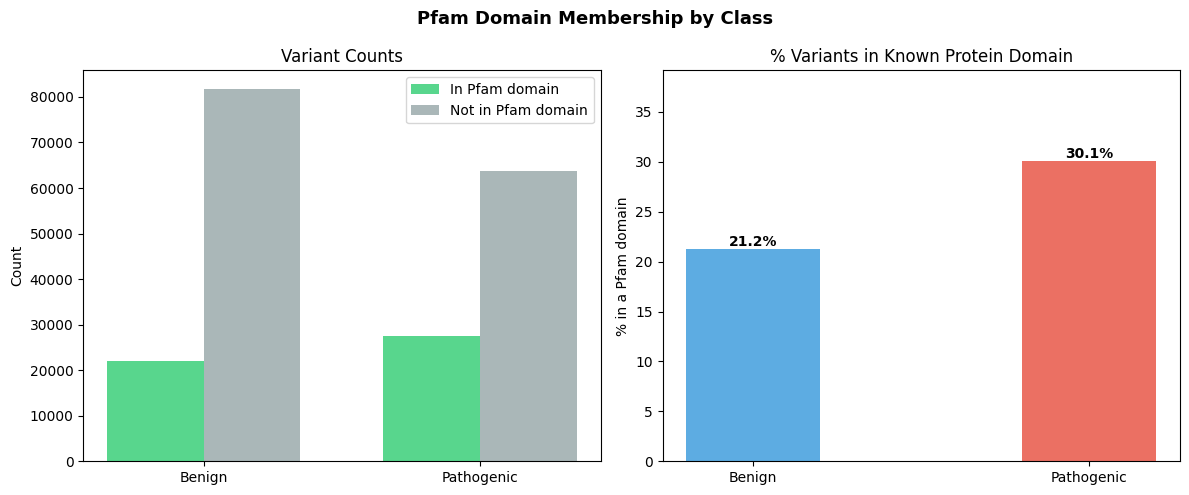

Saved: eda_pfam_domain.png

Pfam domain membership by class:
pfam_domain  False  True 
label                    
0             78.8   21.2
1             69.9   30.1


In [10]:
pfam_stats = train.groupby(['label', 'pfam_domain']).size().unstack(fill_value=0)
pfam_pcts = pfam_stats.div(pfam_stats.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Pfam Domain Membership by Class', fontsize=13, fontweight='bold')

# Counts
x = np.arange(2)
w = 0.35
labels_cls = ['Benign', 'Pathogenic']
in_domain  = [pfam_stats.loc[0, True] if True in pfam_stats.columns else 0,
              pfam_stats.loc[1, True] if True in pfam_stats.columns else 0]
out_domain = [pfam_stats.loc[0, False] if False in pfam_stats.columns else 0,
              pfam_stats.loc[1, False] if False in pfam_stats.columns else 0]

ax1.bar(x - w/2, in_domain,  w, label='In Pfam domain',     color='#2ecc71', alpha=0.8)
ax1.bar(x + w/2, out_domain, w, label='Not in Pfam domain', color='#95a5a6', alpha=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(labels_cls)
ax1.set_ylabel('Count')
ax1.set_title('Variant Counts')
ax1.legend()

# Percentages
in_pcts  = [pfam_pcts.loc[0, True] if True in pfam_pcts.columns else 0,
             pfam_pcts.loc[1, True] if True in pfam_pcts.columns else 0]
ax2.bar(labels_cls, in_pcts, color=[PAL_BEN, PAL_PATH], alpha=0.8, width=0.4)
for j, v in enumerate(in_pcts):
    ax2.text(j, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
ax2.set_ylabel('% in a Pfam domain')
ax2.set_title('% Variants in Known Protein Domain')
ax2.set_ylim(0, max(in_pcts) * 1.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_pfam_domain.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: eda_pfam_domain.png')

print('\nPfam domain membership by class:')
print(pfam_pcts.round(1).to_string())

## 1.11 Key Findings Summary

### The 5 Most Important EDA Findings

**Finding 1 — Conservation scores are the strongest separators:**  
All 6 conservation scores (phyloP, phastCons, GERP++) show clear bimodal separation between Pathogenic and Benign. Pathogenic variants cluster at *highly conserved* positions. This confirms conservation is the primary signal for pathogenicity — consistent with literature.

**Finding 2 — Pathogenic variants are extremely rare in the population:**  
97.6% of all variants have AC=0 (not observed in gnomAD). Among variants *with* measured frequency, benign variants have significantly higher allele frequency. The `is_common` flag (AF > 1%) is near-zero for pathogenic variants — a common variant cannot be highly deleterious (purifying selection removes it).

**Finding 3 — Near-balanced classes with slight benign majority:**  
Training set: 53.2% Benign vs 46.8% Pathogenic. This is a favorable class balance for ML. Gene-level splitting maintained consistent ratios: 53.2% / 44.3% / 50.4% across train/val/test — small shifts are expected due to gene-level granularity.

**Finding 4 — Gene distribution is highly skewed (but expected):**  
A small number of well-studied disease genes (BRCA1, TP53, etc.) dominate variant counts, while thousands of genes have only 1-2 variants. Genes with high pathogenic ratios tend to be known disease genes. Gene-level splitting ensures these dominant genes don't inflate test performance.

**Finding 5 — Missing data is minimal and non-random:**  
All features have <1% missing values. Imputation was applied to a small fraction of conservation scores; `is_imputed_*` flags track this for the model to learn from. The near-complete data quality removes imputation bias as a confound.

## Summary of Saved Figures

| File | Content |
|------|------|
| `eda_class_distribution.png` | Training set bar + stacked split comparison |
| `eda_conservation_scores.png` | 2×3 histograms for all 6 conservation scores |
| `eda_physicochemical.png` | Violin plots for 5 amino acid ref properties |
| `eda_allele_frequency.png` | log_AF histogram + is_common + AC boxplot |
| `eda_correlation_heatmap.png` | Numeric feature correlation matrix |
| `eda_all_features.png` | 5×4 overview of all feature distributions |
| `eda_missing_values.png` | Horizontal bar chart of missing % per feature |
| `eda_gene_distribution.png` | Top 20 genes by count + pathogenic ratio |
| `eda_pfam_domain.png` | Pfam domain membership by class |